## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.models.video import r3d_18, R3D_18_Weights
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 2070 with Max-Q Design


## 2. Dataset Class

Custom dataset that loads videos and their labels.

In [7]:
class RouletteVideoDataset(Dataset):
    """
    Dataset for roulette videos.
    Loads video clips and returns tensor of shape (C, T, H, W)
    where C=3 (RGB), T=num_frames, H=height, W=width
    """
    
    def __init__(self, csv_path, dataset_root, num_frames=16, frame_size=112, transform=None):
        """
        Args:
            csv_path: Path to CSV with columns ['input_path', 'label']
            dataset_root: Root directory of the dataset
            num_frames: Number of frames to sample from each video
            frame_size: Size to resize frames to (frame_size x frame_size)
            transform: Optional transforms to apply
        """
        self.df = pd.read_csv(csv_path)
        # Remove rows with missing labels
        self.df = self.df.dropna(subset=['label']).reset_index(drop=True)
        self.dataset_root = Path(dataset_root)
        self.num_frames = num_frames
        self.frame_size = frame_size
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get video path and label
        video_rel_path = self.df.iloc[idx]['input_path']
        label = int(self.df.iloc[idx]['label'])
        video_path = self.dataset_root / video_rel_path
        
        # Load video frames
        frames = self._load_video(video_path)
        
        # Convert to tensor (C, T, H, W)
        if self.transform:
            frames = self.transform(frames)
        
        return frames, label
    
    def _load_video(self, video_path):
        """Load video and sample num_frames from the BEGINNING (before bets closed)"""
        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Take frames from the beginning only (when bets are still open)
        if total_frames < self.num_frames:
            # If video has fewer frames, repeat last frame
            indices = list(range(total_frames)) + [total_frames-1] * (self.num_frames - total_frames)
        else:
            indices = list(range(self.num_frames))
            # max_frame = min(int(cap.get(cv2.CAP_PROP_FPS) * 2), total_frames-1)
            # indices = np.linspace(0, max_frame, self.num_frames, dtype=int)
        
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                # Convert BGR to RGB
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                # Resize
                frame = cv2.resize(frame, (self.frame_size, self.frame_size))
                # Normalize to [0, 1]
                frame = frame.astype(np.float32) / 255.0
                frames.append(frame)
        
        cap.release()
        
        # Stack frames: (T, H, W, C)
        frames = np.stack(frames, axis=0)
        
        # Convert to (C, T, H, W) for PyTorch
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2)
        
        return frames

## 3. Model Architecture

Using ResNet3D (R3D-18) pre-trained on Kinetics-400.
We'll replace the final classification layer to output 37 classes.

In [8]:
class RoulettePredictor(nn.Module):
    """
    Video classification model for roulette prediction.
    Based on ResNet3D (R3D-18) with pre-trained weights.
    """
    
    def __init__(self, num_classes=37, freeze_backbone=True):
        """
        Args:
            num_classes: Number of roulette numbers (0-36, so 37 classes)
            freeze_backbone: If True, only train the final layer
        """
        super(RoulettePredictor, self).__init__()
        
        # Load pre-trained R3D-18
        weights = R3D_18_Weights.KINETICS400_V1
        self.model = r3d_18(weights=weights)
        
        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False
        
        # Replace final FC layer
        # R3D-18 has fc layer with in_features=512
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        """
            x: (batch, C, T, H, W)
        Returns:
            Logits of shape (batch, num_classes)
        """
        return self.model(x)
    
    def unfreeze_backbone(self):
        """Unfreeze all layers for fine-tuning"""
        for param in self.model.parameters():
            param.requires_grad = True

# Test model creation
model = RoulettePredictor(num_classes=37, freeze_backbone=True)
print(f"✅ Model created successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

✅ Model created successfully!
Total parameters: 33,307,109
Trainable parameters: 140,837


## 4. Training Setup

Define loss function, optimizer, and training loop.

In [10]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    correct_top5 = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for videos, labels in pbar:
        videos, labels = videos.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * videos.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Top-5 accuracy
        _, top5_pred = outputs.topk(5, 1, True, True)
        top5_pred = top5_pred.t()
        correct_top5 += top5_pred.eq(labels.view(1, -1).expand_as(top5_pred)).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': loss.item(), 
            'acc': 100 * correct / total,
            'top5': 100 * correct_top5 / total
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    epoch_top5_acc = 100 * correct_top5 / total
    return epoch_loss, epoch_acc, epoch_top5_acc

def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    correct = 0
    correct_top5 = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for videos, labels in pbar:
            videos, labels = videos.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(videos)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * videos.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Top-5 accuracy
            _, top5_pred = outputs.topk(5, 1, True, True)
            top5_pred = top5_pred.t()
            correct_top5 += top5_pred.eq(labels.view(1, -1).expand_as(top5_pred)).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({
                'loss': loss.item(), 
                'acc': 100 * correct / total,
                'top5': 100 * correct_top5 / total
            })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    epoch_top5_acc = 100 * correct_top5 / total
    return epoch_loss, epoch_acc, epoch_top5_acc, all_preds, all_labels

print("Training functions defined!")

Training functions defined!


## 5. Load Dataset & Create DataLoaders

**NOTE**: Before running this, you need:
1. A CSV file with columns: `input_path`, `label`
2. Labels should be integers from 0-36

Update the paths below once you have the labeled data.

In [ ]:
# Configuration
CONFIG = {
    'dataset_root': 'RouletteVision-Dataset',
    'csv_path': 'dataset_labels_combined.csv',  # Update this with your labeled CSV
    'num_frames': 16,
    'frame_size': 112,
    'batch_size': 8,
    'num_workers': 0,
    'train_split': 0.8,
    'learning_rate': 1e-3,
    'num_epochs': 20,
    'save_path': 'roulette_model.pth'
}

# Create dataset (only when you have labels)
# Uncomment when ready:
dataset = RouletteVideoDataset(
    csv_path=CONFIG['csv_path'],
    dataset_root=CONFIG['dataset_root'],
    num_frames=CONFIG['num_frames'],
    frame_size=CONFIG['frame_size']
)

# Split into train/val
train_size = int(CONFIG['train_split'] * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create sampler for training to handle class imbalance
all_labels = [int(dataset.df.iloc[i]['label']) for i in range(len(dataset))]
train_labels = [all_labels[idx] for idx in train_dataset.indices]

# Count class occurrences in training set
class_counts = np.bincount(train_labels, minlength=37)
class_weights = 1.0 / (class_counts + 1e-6)  # Add small epsilon to avoid division by zero

# Assign weight to each training sample based on its class
sample_weights = [class_weights[label] for label in train_labels]

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    sampler=train_sampler,
    num_workers=CONFIG['num_workers'], 
    pin_memory=True, 
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"✅ Dataset loaded: {len(dataset)} videos")
print(f"   Training: {train_size} videos")
print(f"   Validation: {val_size} videos")

print("Configuration set. Uncomment code above when labels are ready.")

✅ Dataset loaded: 1703 videos
   Training: 1362 videos
   Validation: 341 videos
Configuration set. Uncomment code above when labels are ready.


In [12]:
# Test data loading - check what train_loader outputs
print("Testing train_loader...")
print(f"Total batches in train_loader: {len(train_loader)}")
print(f"Batch size: {CONFIG['batch_size']}")

# Load first batch
print("\n" + "="*60)
print("Loading first batch...")
batch_videos, batch_labels = next(iter(train_loader))

print(f"\n✅ Successfully loaded batch!")
print(f"Videos shape: {batch_videos.shape}")  # Should be (batch, C, T, H, W)
print(f"Labels shape: {batch_labels.shape}")  # Should be (batch,)
print(f"Videos dtype: {batch_videos.dtype}")
print(f"Labels dtype: {batch_labels.dtype}")
print(f"Videos range: [{batch_videos.min():.3f}, {batch_videos.max():.3f}]")
print(f"Labels: {batch_labels.tolist()}")

# Test loading a few more batches to see if it's slow
print("\n" + "="*60)
print("Loading 3 more batches to test speed...")
import time
for i in range(3):
    start = time.time()
    videos, labels = next(iter(train_loader))
    elapsed = time.time() - start
    print(f"Batch {i+1}: {elapsed:.2f}s - Videos: {videos.shape}, Labels: {labels.shape}")

print("\n✅ Data loading test complete!")

Testing train_loader...
Total batches in train_loader: 171
Batch size: 8

Loading first batch...

✅ Successfully loaded batch!
Videos shape: torch.Size([8, 3, 16, 112, 112])
Labels shape: torch.Size([8])
Videos dtype: torch.float32
Labels dtype: torch.int64
Videos range: [0.000, 1.000]
Labels: [19, 31, 34, 36, 29, 12, 30, 3]

Loading 3 more batches to test speed...
Batch 1: 2.17s - Videos: torch.Size([8, 3, 16, 112, 112]), Labels: torch.Size([8])
Batch 2: 2.37s - Videos: torch.Size([8, 3, 16, 112, 112]), Labels: torch.Size([8])
Batch 3: 2.53s - Videos: torch.Size([8, 3, 16, 112, 112]), Labels: torch.Size([8])

✅ Data loading test complete!


## 6. Training Loop

Main training loop - run this to train the model.

In [ ]:
# Training function
def train_model(model, train_loader, val_loader, config, device):
    """Full training loop"""
    
    # Setup
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['learning_rate']
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True
    )
    
    # Move model to device
    model = model.to(device)
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [], 'train_top5_acc': [],
        'val_loss': [], 'val_acc': [], 'val_top5_acc': []
    }
    
    best_val_acc = 0.0
    best_val_top5_acc = 0.0
    
    print(f"\n{'='*60}")
    print(f"Starting training for {config['num_epochs']} epochs")
    print(f"{'='*60}\n")
    
    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        print("-" * 60)
        
        # Train
        train_loss, train_acc, train_top5_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc, val_top5_acc, _, _ = validate_epoch(model, val_loader, criterion, device)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_top5_acc'].append(train_top5_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_top5_acc'].append(val_top5_acc)
        
        # Print epoch summary
        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Train Top-5: {train_top5_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}% | Val Top-5:   {val_top5_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_top5_acc = val_top5_acc
            torch.save(model.state_dict(), config['save_path'])
            print(f"  ✅ New best model saved! (Val Acc: {val_acc:.2f}%, Top-5: {val_top5_acc:.2f}%)")
    
    print(f"\n{'='*60}")
    print(f"Training completed!")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Best validation top-5 accuracy: {best_val_top5_acc:.2f}%")
    print(f"Model saved to: {config['save_path']}")
    print(f"{'='*60}\n")
    
    return history

# Uncomment to train when data is ready:
history = train_model(model, train_loader, val_loader, CONFIG, device)

c:\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Starting training for 20 epochs


Epoch 1/20
------------------------------------------------------------


Training:   0%|          | 0/171 [00:00<?, ?it/s]

Validation: 100%|██████████| 43/43 [01:55<00:00,  2.68s/it, loss=3.63, acc=2.93, top5=14.7] 



Epoch 1 Summary:
  Train Loss: 3.6652 | Train Acc: 2.06% | Train Top-5: 13.22%
  Val Loss:   3.6221 | Val Acc:   2.93% | Val Top-5:   14.66%
  ✅ New best model saved! (Val Acc: 2.93%, Top-5: 14.66%)

Epoch 2/20
------------------------------------------------------------


...


Epoch 18 Summary:
  Train Loss: 3.5809 | Train Acc: 4.04% | Train Top-5: 18.28%
  Val Loss:   3.6363 | Val Acc:   2.05% | Val Top-5:   14.96%

Epoch 19/20
------------------------------------------------------------


Validation: 100%|██████████| 43/43 [02:02<00:00,  2.85s/it, loss=3.59, acc=2.35, top5=15.5]



Epoch 19 Summary:
  Train Loss: 3.5811 | Train Acc: 4.41% | Train Top-5: 18.28%
  Val Loss:   3.6349 | Val Acc:   2.35% | Val Top-5:   15.54%

Epoch 20/20
------------------------------------------------------------


Validation: 100%|██████████| 43/43 [02:03<00:00,  2.87s/it, loss=3.6, acc=2.35, top5=15.2] 


Epoch 20 Summary:
  Train Loss: 3.5846 | Train Acc: 4.04% | Train Top-5: 19.60%
  Val Loss:   3.6347 | Val Acc:   2.35% | Val Top-5:   15.25%

Training completed!
Best validation accuracy: 3.52%
Best validation top-5 accuracy: 16.13%
Model saved to: roulette_model.pth



## 6.5. Save Training Results

Save history and data split for reproducibility.

In [16]:
import pickle
import json

# Save training history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)
print("✅ Training history saved to 'training_history.pkl'")

# Also save as JSON for readability
with open('training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print("✅ Training history saved to 'training_history.json'")

# Save train/val split indices for reproducibility
split_info = {
    'train_indices': train_dataset.indices,
    'val_indices': val_dataset.indices,
    'train_size': len(train_dataset),
    'val_size': len(val_dataset),
    'total_size': len(dataset),
    'config': CONFIG
}

with open('train_val_split.pkl', 'wb') as f:
    pickle.dump(split_info, f)
print("✅ Train/val split info saved to 'train_val_split.pkl'")

print(f"\n📊 Saved:")
print(f"   - training_history.pkl / .json")
print(f"   - train_val_split.pkl")
print(f"   - {CONFIG['save_path']} (model weights)")


✅ Training history saved to 'training_history.pkl'
✅ Training history saved to 'training_history.json'
✅ Train/val split info saved to 'train_val_split.pkl'

📊 Saved:
   - training_history.pkl / .json
   - train_val_split.pkl
   - roulette_model.pth (model weights)


### How to Restore Later

To restore your training results and recreate graphs:

In [ ]:
# Load training history
with open('training_history.pkl', 'rb') as f:
    history = pickle.load(f)
print("✅ Training history loaded")

# Load split info and recreate val_loader
with open('train_val_split.pkl', 'rb') as f:
    split_info = pickle.load(f)

# Recreate dataset
dataset = RouletteVideoDataset(
    csv_path=split_info['config']['csv_path'],
    dataset_root=split_info['config']['dataset_root'],
    num_frames=split_info['config']['num_frames'],
    frame_size=split_info['config']['frame_size']
)

# Recreate exact same train/val split using saved indices
from torch.utils.data import Subset
train_dataset = Subset(dataset, split_info['train_indices'])
val_dataset = Subset(dataset, split_info['val_indices'])

val_loader = DataLoader(
    val_dataset,
    batch_size=split_info['config']['batch_size'],
    shuffle=False,
    num_workers=split_info['config']['num_workers'],
    pin_memory=True
)
print("✅ Validation loader recreated with exact same split")

# Load model weights
model = RoulettePredictor(num_classes=37, freeze_backbone=True)
model.load_state_dict(torch.load(split_info['config']['save_path']))
model = model.to(device)
print("✅ Model weights loaded")

# Now you can recreate all graphs and evaluations
plot_training_history(history)
final_acc = evaluate_model(model, val_loader, device)

## 7. Visualization & Evaluation

Plot training curves and evaluate model performance.

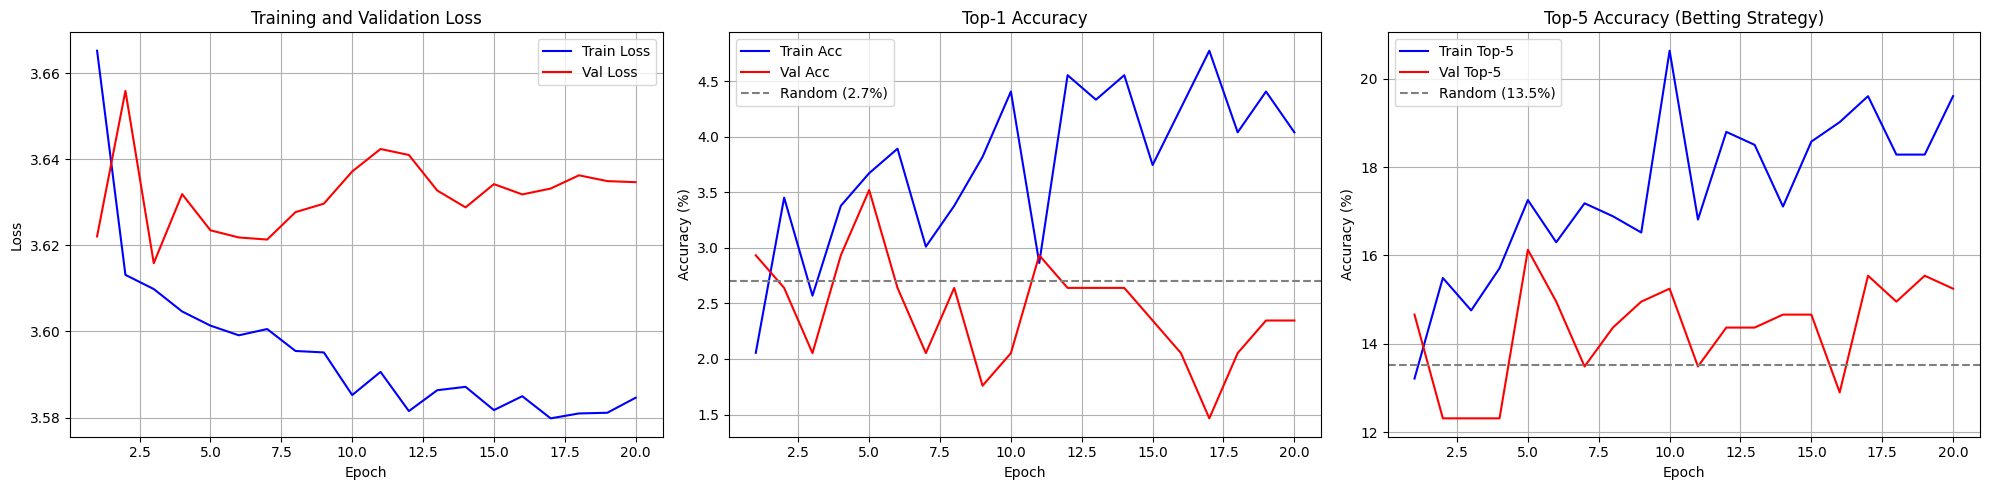

Validation: 100%|██████████| 43/43 [01:56<00:00,  2.70s/it, loss=3.6, acc=2.35, top5=15.2] 
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is


Final Evaluation Results
Validation Loss: 3.6347

Top-1 Accuracy (single bet):
  Model: 2.35%
  Random Baseline: 2.70%
  Improvement: 0.87x over random

Top-5 Accuracy (spread betting strategy):
  Model: 15.25%
  Random Baseline: 13.51%
  Improvement: 1.13x over random

Expected value (betting 1 unit on each of top 5):
  Cost per spin: 5 units
  Win payout: 36 units (35:1 + original bet)
  Expected return: 5.49 units
  Expected profit per spin: 0.49 units
  Break-even top-5 accuracy: 13.89%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00        10
           4       0.00      0.00      0.00        11
           5       0.00      0.00      0.00        13
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00   

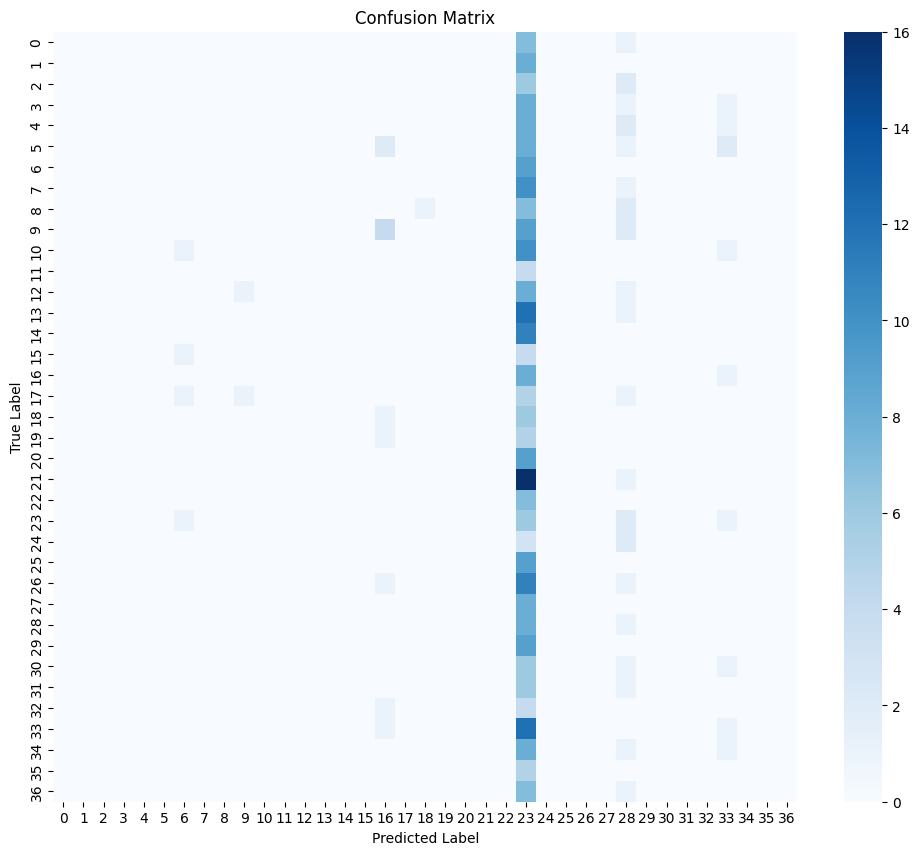

Evaluation functions ready!


In [15]:
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss plot
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Top-1 Accuracy plot
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], 'r-', label='Val Acc')
    ax2.axhline(y=100/37, color='gray', linestyle='--', label='Random (2.7%)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Top-1 Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    # Top-5 Accuracy plot
    ax3.plot(epochs, history['train_top5_acc'], 'b-', label='Train Top-5')
    ax3.plot(epochs, history['val_top5_acc'], 'r-', label='Val Top-5')
    ax3.axhline(y=100*5/37, color='gray', linestyle='--', label='Random (13.5%)')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Accuracy (%)')
    ax3.set_title('Top-5 Accuracy (Betting Strategy)')
    ax3.legend()
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, val_loader, device):
    """Detailed model evaluation"""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    val_loss, val_acc, val_top5_acc, all_preds, all_labels = validate_epoch(
        model, val_loader, criterion, device
    )
    
    print(f"\n{'='*60}")
    print("Final Evaluation Results")
    print(f"{'='*60}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"\nTop-1 Accuracy (single bet):")
    print(f"  Model: {val_acc:.2f}%")
    print(f"  Random Baseline: {100/37:.2f}%")
    print(f"  Improvement: {val_acc / (100/37):.2f}x over random")
    print(f"\nTop-5 Accuracy (spread betting strategy):")
    print(f"  Model: {val_top5_acc:.2f}%")
    print(f"  Random Baseline: {100*5/37:.2f}%")
    print(f"  Improvement: {val_top5_acc / (100*5/37):.2f}x over random")
    print(f"\nExpected value (betting 1 unit on each of top 5):")
    print(f"  Cost per spin: 5 units")
    print(f"  Win payout: 36 units (35:1 + original bet)")
    print(f"  Expected return: {val_top5_acc/100 * 36:.2f} units")
    print(f"  Expected profit per spin: {val_top5_acc/100 * 36 - 5:.2f} units")
    print(f"  Break-even top-5 accuracy: {5/36*100:.2f}%")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(37)]))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return val_acc

# Uncomment after training:
plot_training_history(history)
final_acc = evaluate_model(model, val_loader, device)

print("Evaluation functions ready!")

## 8. Inference Function

Make predictions on new videos.

In [12]:
def predict_video(model, video_path, dataset_root, num_frames=16, frame_size=112, device='cuda'):
    """
    Predict roulette outcome for a single video
    
    Returns:
        predicted_number: Most likely number (0-36)
        probabilities: Probability distribution over all 37 numbers
    """
    model.eval()
    
    # Create temporary dataset for single video
    # (In practice, you'd load the video directly)
    temp_df = pd.DataFrame([{
        'input_path': video_path,
        'label': 0  # Dummy label
    }])
    temp_csv = 'temp_inference.csv'
    temp_df.to_csv(temp_csv, index=False)
    
    dataset = RouletteVideoDataset(
        csv_path=temp_csv,
        dataset_root=dataset_root,
        num_frames=num_frames,
        frame_size=frame_size
    )
    
    video_tensor, _ = dataset[0]
    video_tensor = video_tensor.unsqueeze(0).to(device)  # Add batch dimension
    
    with torch.no_grad():
        outputs = model(video_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_number = torch.argmax(probabilities).item()
    
    # Clean up
    Path(temp_csv).unlink()
    
    return predicted_number, probabilities.cpu().numpy()

# Example usage (uncomment after training):
# video_path = 'Input-Output Videos/SET 1/S1_INPUT_1.mp4'
# pred_num, probs = predict_video(model, video_path, CONFIG['dataset_root'], device=device)
# print(f"Predicted number: {pred_num}")
# print(f"Confidence: {probs[pred_num]*100:.2f}%")
# 
# # Show top 5 predictions
# top5_indices = np.argsort(probs)[-5:][::-1]
# print("\nTop 5 predictions:")
# for idx in top5_indices:
#     print(f"  Number {idx}: {probs[idx]*100:.2f}%")

print("Inference function ready!")

Inference function ready!


## 9. Summary & Next Steps

### What we have:
- ✅ Dataset class for loading videos
- ✅ Pre-trained ResNet3D model with custom classification head
- ✅ Training and validation loops
- ✅ Evaluation and visualization functions
- ✅ Inference function for new videos

### To start training:
1. **Get labels**: Create `dataset_labels.csv` with columns `input_path` and `label` (0-36)
2. **Uncomment data loading** in cell 6
3. **Run training** by uncommenting cell 7
4. **Evaluate** using cell 8

### Expected timeline:
- Data preparation: 2-3 hours
- Training (20 epochs): 4-6 hours
- Evaluation & demo prep: 2-3 hours

### Expected performance:
- Random baseline: ~2.7% accuracy
- Target: 8-15% accuracy (3-5x better than random)
- Good result: >30% top-5 accuracy